# NYC Restaurant Inspections Data Analysis
---
## Research Question
How does restaurant health inspection risk vary across neighborhoods in New York City, and what does that variation suggest about the relationship between neighborhood conditions and food safety outcomes?

## Datasets
[New York City Restaurant Inspection Results](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data)

[New York City Rodent Inspections](https://data.cityofnewyork.us/Health/Rodent-Inspection/p937-wjvj/about_data)

[New York City Income Dataset TO BE LOADED]

[New York City 311 Complaint Dataset](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data)

---

## Table of Contents

1.   Setup
2.   Data Loading
3.   Restaurant Inspection Data Analysis (Cleaning, Exploration, Visualization)
4.   Rodent Inspection Data Analysis (Cleaning, Exploration, Visualization)
5.   Socioeconomic Data Analysis (Cleaning, Exploration, Visualization)
6.   311 Complaint Data Analysis (Cleaning, Exploration, Visualization)
---


## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

---

## Data Loading

In [2]:
base_url = "https://data.cityofnewyork.us/resource/43nn-pn8j.csv"

params = {
    "$select": "camis,dba,boro,zipcode,cuisine_description,inspection_date,critical_flag,score,grade,latitude,longitude",
    "$where": "boro='Queens' AND inspection_date>'2023-01-01T00:00:00'",
    "$limit": 300000
}

response = requests.get(base_url, params=params)
inspections_df = pd.read_csv(StringIO(response.text))

In [3]:
base_url = "https://data.cityofnewyork.us/resource/p937-wjvj.csv"

params = {
    "$select": "inspection_type,zip_code,borough,inspection_date,result,latitude,longitude",
    "$where": "borough='Queens' AND inspection_date>'2023-01-01T00:00:00'",
    "$limit": 300000
}

response = requests.get(base_url, params=params)
rodents_df = pd.read_csv(StringIO(response.text))

In [4]:
base_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

params = {
    "$select": "created_date,agency,complaint_type,descriptor,borough,latitude,longitude",
    "$where": "borough='QUEENS' AND created_date>'2023-01-01T00:00:00'",
    "$limit": 3000000
}

response = requests.get(base_url, params=params)
complaints_df = pd.read_csv(StringIO(response.text))

In [70]:
# Data Visualization Setup
sns.set_theme(style="whitegrid")
inspection_colors = sns.color_palette("Purples_d")
rodent_colors = sns.color_palette("Reds")
complaints_colors = sns.color_palette("Oranges_d")

---

## Restaraunt Inspection Data Analysis (Cleaning, Exploration, Visualization)

In [5]:
inspections_df.shape

(68607, 11)

In [6]:
inspections_df.columns

Index(['camis', 'dba', 'boro', 'zipcode', 'cuisine_description',
       'inspection_date', 'critical_flag', 'score', 'grade', 'latitude',
       'longitude'],
      dtype='str')

In [7]:
inspections_df.head()

,camis,dba,boro,zipcode,cuisine_description,inspection_date,critical_flag,score,grade,latitude,longitude
0,41629692,DUNKIN,Queens,11430.0,Donuts,2024-06-20T00:00:00.000,Not Critical,33.0,NaN,NaN,NaN
1,50134692,MILAGRO TEQUILA BAR,Queens,NaN,American,2023-04-17T00:00:00.000,Not Applicable,0.0,NaN,0.000000,0.000000
2,50107193,NUTRIPLATES,Queens,NaN,American,2024-07-15T00:00:00.000,Not Critical,18.0,NaN,0.000000,0.000000
3,50075574,XIN BAO,Queens,11434.0,Chinese,2026-05-20T00:00:00.000,Not Applicable,NaN,NaN,40.671631,-73.774368
4,50134414,JACKSON DINER,Queens,NaN,Indian,2024-12-02T00:00:00.000,Critical,25.0,NaN,0.000000,0.000000


In [8]:
inspections_df.isna().sum()

camis                      0
dba                        0
boro                       0
zipcode                  525
cuisine_description        0
inspection_date            0
critical_flag              0
score                   3465
grade                  35478
latitude                 423
longitude                423
dtype: int64

In [27]:
inspections_df['cuisine_description'].value_counts()

cuisine_description
Chinese                      9695
American                     7004
Latin American               6652
Bakery Products/Desserts     3685
Caribbean                    3440
                             ... 
Not Listed/Not Applicable       5
Ethiopian                       4
Chimichurri                     4
Southwestern                    2
Californian                     1
Name: count, Length: 81, dtype: int64

In [28]:
inspections_df['critical_flag'].value_counts()

critical_flag
Critical          36799
Not Critical      30864
Not Applicable      944
Name: count, dtype: int64

In [29]:
inspections_df['grade'].value_counts()

grade
A    20780
B     4795
C     3702
N     2163
Z     1490
P      199
Name: count, dtype: int64

### Key Metrics:

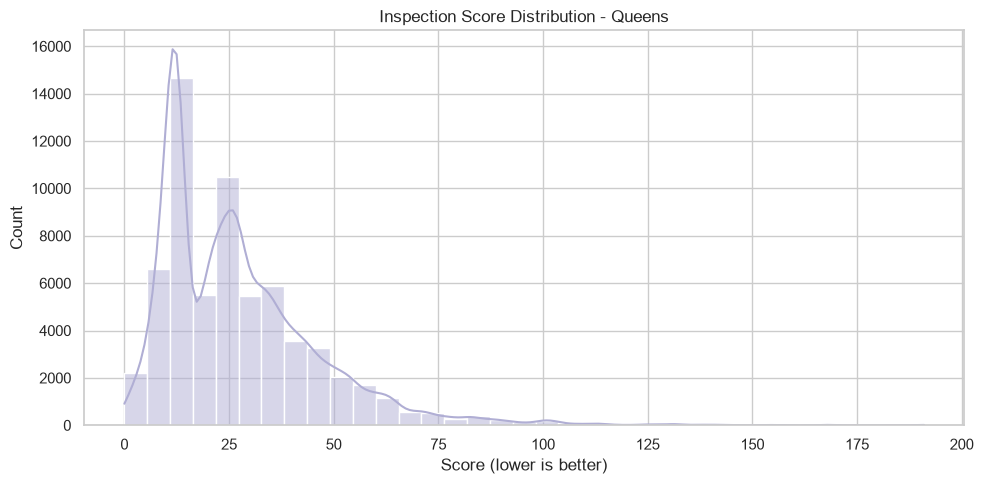

In [43]:
# Inspection Score Distribution - Queens
plt.figure(figsize=(10, 5))
sns.histplot(inspections_df['score'].dropna(), bins=35, color=inspection_colors[0], kde=True)
plt.title('Inspection Score Distribution - Queens')
plt.xlabel('Score (lower is better)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_760\4091679148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette=inspection_colors)


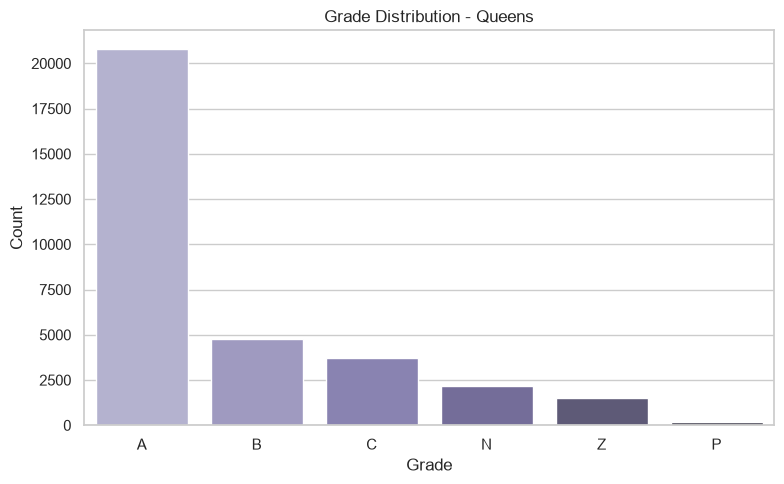

In [44]:
# Grade Distribution - Queens
grade_counts = inspections_df['grade'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette=inspection_colors)
plt.title('Grade Distribution - Queens')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

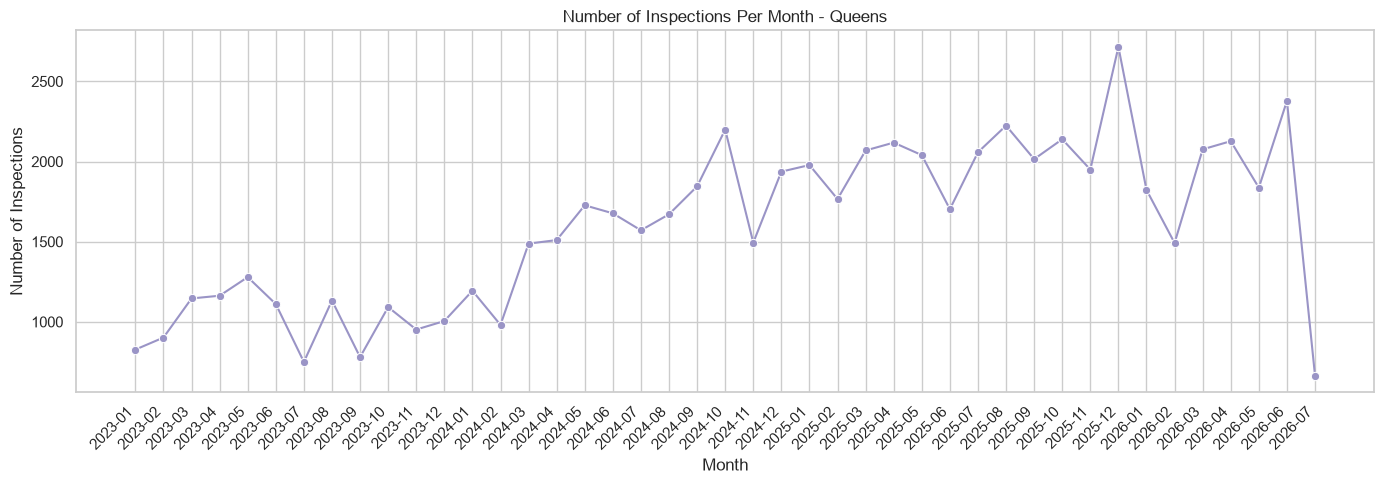

In [45]:
# Number of Inspections Per Year - Queens
inspections_df['month'] = pd.to_datetime(inspections_df['inspection_date']).dt.to_period('M')
month_counts = inspections_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=month_counts.index.astype(str), y=month_counts.values, marker='o', color=inspection_colors[1])
plt.title('Number of Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_760\1986180202.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Purples_d")


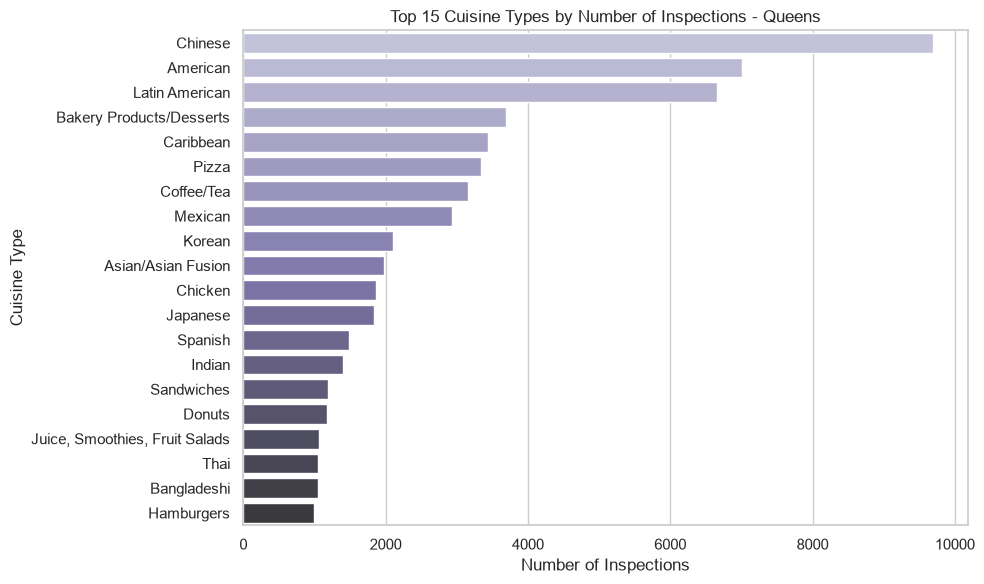

In [49]:
# Top 20 Cuisine Types by Number of Inspections - Queens
top_cuisines = inspections_df['cuisine_description'].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Purples_d")
plt.title('Top 15 Cuisine Types by Number of Inspections - Queens')
plt.xlabel('Number of Inspections')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.show()

---

## Rodent Inspection Data Analysis (Cleaning, Exploration, Visualization)

In [22]:
rodents_df.shape

(49781, 7)

In [23]:
rodents_df.columns

Index(['inspection_type', 'zip_code', 'borough', 'inspection_date', 'result',
       'latitude', 'longitude'],
      dtype='str')

In [24]:
rodents_df.head()

,inspection_type,zip_code,borough,inspection_date,result,latitude,longitude
0,Treatments,11433.0,Queens,2026-04-21T11:40:36.000,Bait applied,40.705653,-73.792109
1,Initial,11691.0,Queens,2026-02-27T10:30:57.000,Passed,40.606437,-73.752314
2,Initial,11434.0,Queens,2026-01-15T13:16:31.000,Passed,40.663249,-73.769217
3,Compliance,11434.0,Queens,2026-01-15T10:56:21.000,Passed,40.666955,-73.771003
4,Initial,11414.0,Queens,2023-05-24T15:00:04.000,Passed,40.654139,-73.830804


In [25]:
rodents_df.isna().sum()

inspection_type      0
zip_code           216
borough              0
inspection_date      0
result               0
latitude           187
longitude          187
dtype: int64

In [26]:
rodents_df['inspection_type'].value_counts()

inspection_type
Initial       27974
Compliance    11891
Treatments     9742
Clean Ups       130
Stoppage         44
Name: count, dtype: int64

In [20]:
rodents_df['result'].value_counts()

result
Passed                                      21490
Failed for Rat Activity                      9151
Bait applied                                 9006
Failed for Other Reason                      5306
Failed for Rat Activity and Other Reason     3918
Monitoring visit                              736
Cleanup done                                  130
Stoppage done                                  44
Name: count, dtype: int64

### Key Metrics:

C:\Users\chena\AppData\Local\Temp\ipykernel_760\2695707273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)
C:\Users\chena\AppData\Local\Temp\ipykernel_760\2695707273.py:4: UserWarning: 
The palette list has fewer values (6) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)


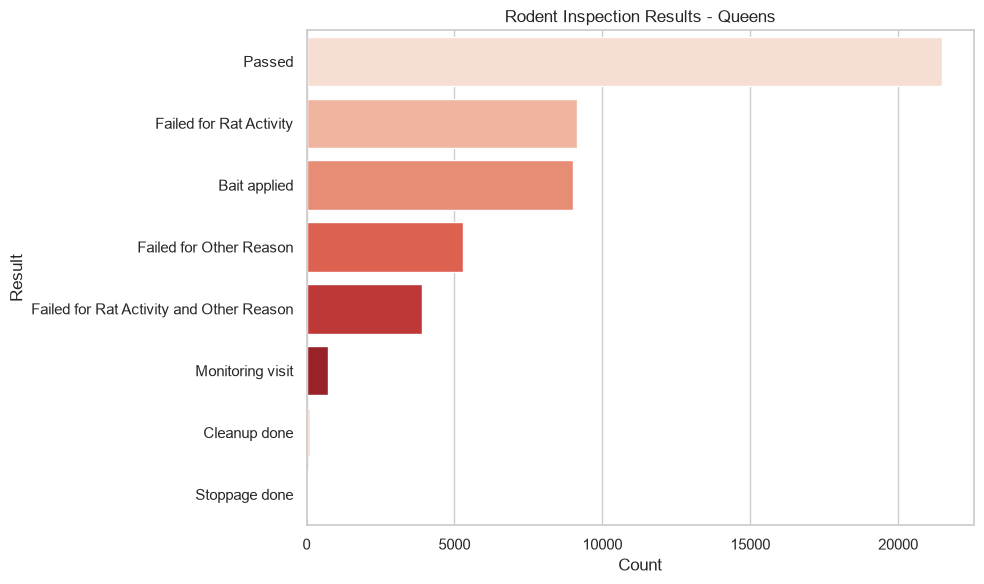

In [50]:
result_counts = rodents_df['result'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)
plt.title('Rodent Inspection Results - Queens')
plt.xlabel('Count')
plt.ylabel('Result')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_760\3472836620.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)
C:\Users\chena\AppData\Local\Temp\ipykernel_760\3472836620.py:4: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)


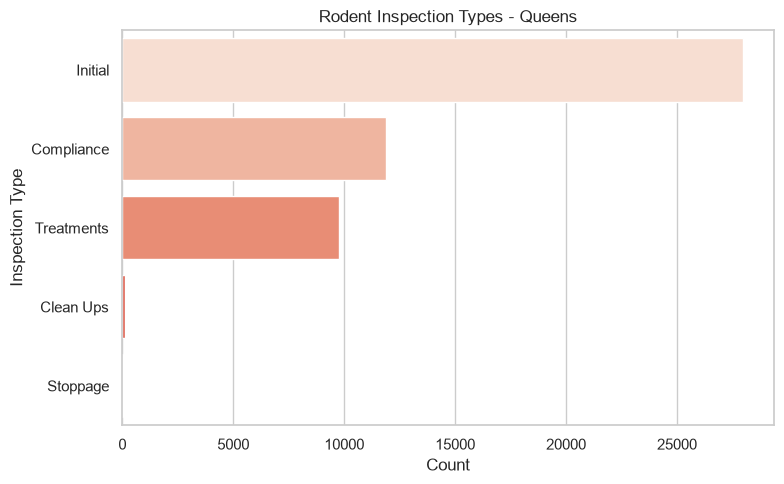

In [52]:
type_counts = rodents_df['inspection_type'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)
plt.title('Rodent Inspection Types - Queens')
plt.xlabel('Count')
plt.ylabel('Inspection Type')
plt.tight_layout()
plt.show()

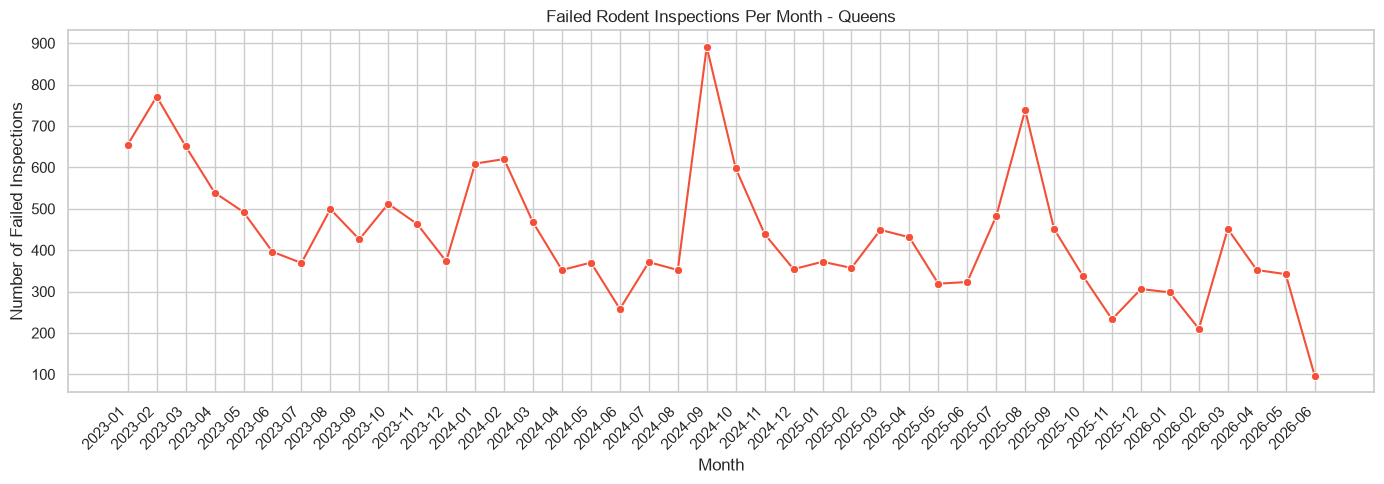

In [51]:
rodents_df['month'] = pd.to_datetime(rodents_df['inspection_date']).dt.to_period('M')

failed_df = rodents_df[rodents_df['result'].str.contains('Failed', na=False)]
failed_monthly = failed_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=failed_monthly.index.astype(str), y=failed_monthly.values, marker='o', color=rodent_colors[3])
plt.title('Failed Rodent Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Failed Inspections')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

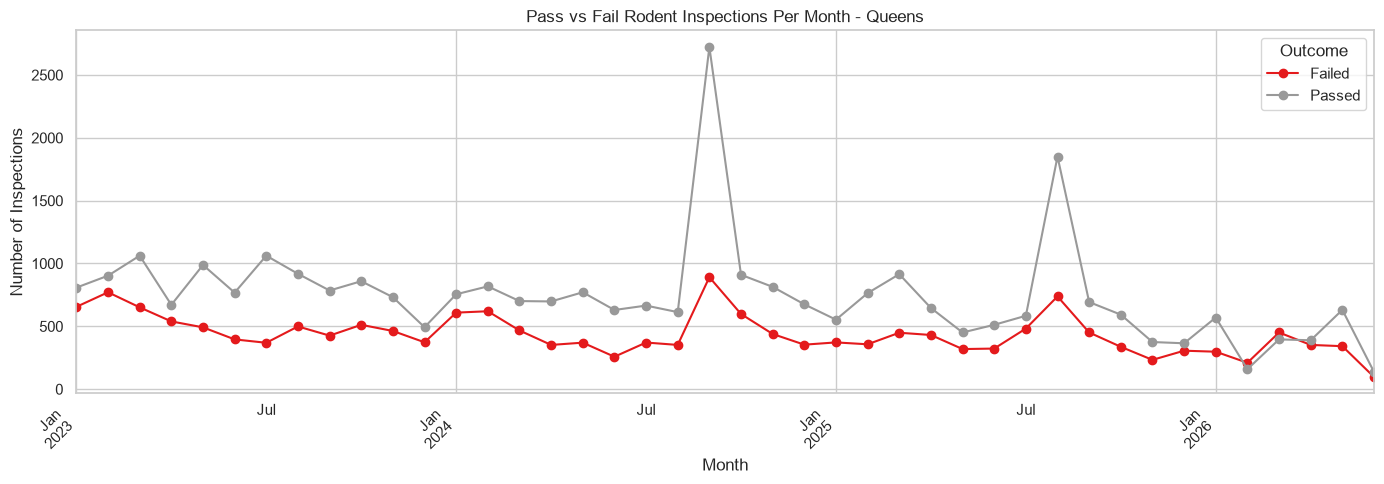

In [53]:
rodents_df['outcome'] = rodents_df['result'].apply(
    lambda x: 'Failed' if 'Failed' in str(x) else 'Passed'
)

outcome_monthly = rodents_df.groupby(['month', 'outcome']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
outcome_monthly.plot(kind='line', marker='o', colormap='Set1', ax=plt.gca())
plt.title('Pass vs Fail Rodent Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Outcome')
plt.tight_layout()

plt.show()

---

## 311 Complaints Data Analysis (Cleaning, Exploration, Visualization)

In [54]:
complaints_df.shape

(3000000, 7)

In [56]:
complaints_df.columns

Index(['created_date', 'agency', 'complaint_type', 'descriptor', 'borough',
       'latitude', 'longitude'],
      dtype='str')

In [55]:
complaints_df.head()

,created_date,agency,complaint_type,descriptor,borough,latitude,longitude
0,2026-07-13T03:04:13.000,DOT,Street Condition,Pothole,QUEENS,NaN,NaN
1,2026-07-13T01:46:44.000,NYPD,Noise - Residential,Banging/Pounding,QUEENS,40.706051,-73.831408
2,2026-07-13T01:46:42.000,DSNY,Illegal Dumping,Removal Request,QUEENS,40.696788,-73.899287
3,2026-07-13T01:43:03.000,NYPD,Illegal Fireworks,NaN,QUEENS,40.585051,-73.817900
4,2026-07-13T01:42:47.000,NYPD,Noise - Residential,Banging/Pounding,QUEENS,40.602241,-73.754029


In [57]:
complaints_df.isna().sum()

created_date          0
agency                0
complaint_type        0
descriptor        44680
borough               0
latitude          75984
longitude         75984
dtype: int64

In [58]:
complaints_df['agency'].value_counts()

agency
NYPD          1534885
HPD            343205
DSNY           295320
DOT            251468
DEP            180710
DPR            146797
DOB             95547
DOHMH           60809
EDC             27225
TLC             26105
DHS             19052
DCWP            16418
DOE              1481
OOS               752
OTI               121
NYC311-PRD        104
3-1-1               1
Name: count, dtype: int64

In [61]:
complaints_df['complaint_type'].value_counts().head(20)

complaint_type
Illegal Parking             574450
Blocked Driveway            258555
Noise - Residential         257091
HEAT/HOT WATER              134954
Street Condition            108337
Abandoned Vehicle           100956
Noise - Street/Sidewalk      92086
Water System                 65315
UNSANITARY CONDITION         58770
Drug Activity                58203
Derelict Vehicles            54713
Noise - Commercial           48001
Noise - Vehicle              47215
Dirty Condition              46974
Traffic Signal Condition     46641
Missed Collection            45820
Damaged Tree                 44448
Sewer                        40880
Illegal Dumping              38366
Noise                        37590
Name: count, dtype: int64

In [60]:
complaints_df['descriptor'].value_counts()

descriptor
Loud Music/Party                 270981
No Access                        185455
Blocked Hydrant                  179989
Posted Parking Sign Violation    114281
With License Plate               100956
                                  ...  
Dirt, Litter, Debris - Garage         1
Supervisory                           1
User Unlicensed                       1
Debris                                1
Ticket Broker                         1
Name: count, Length: 1034, dtype: int64

### Key Metrics

C:\Users\chena\AppData\Local\Temp\ipykernel_760\4250082746.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_complaints.values, y=top_complaints.index, palette="Oranges_d")


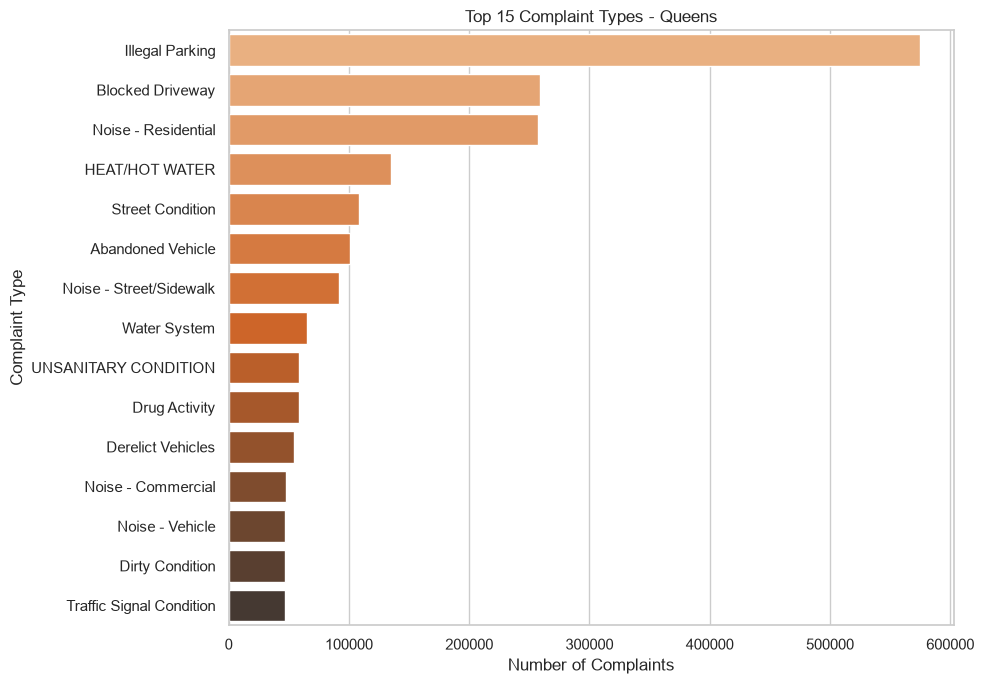

In [72]:
top_complaints = complaints_df['complaint_type'].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_complaints.values, y=top_complaints.index, palette="Oranges_d")
plt.title('Top 15 Complaint Types - Queens')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_760\939093494.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agency_counts.values, y=agency_counts.index, palette="Oranges_d")


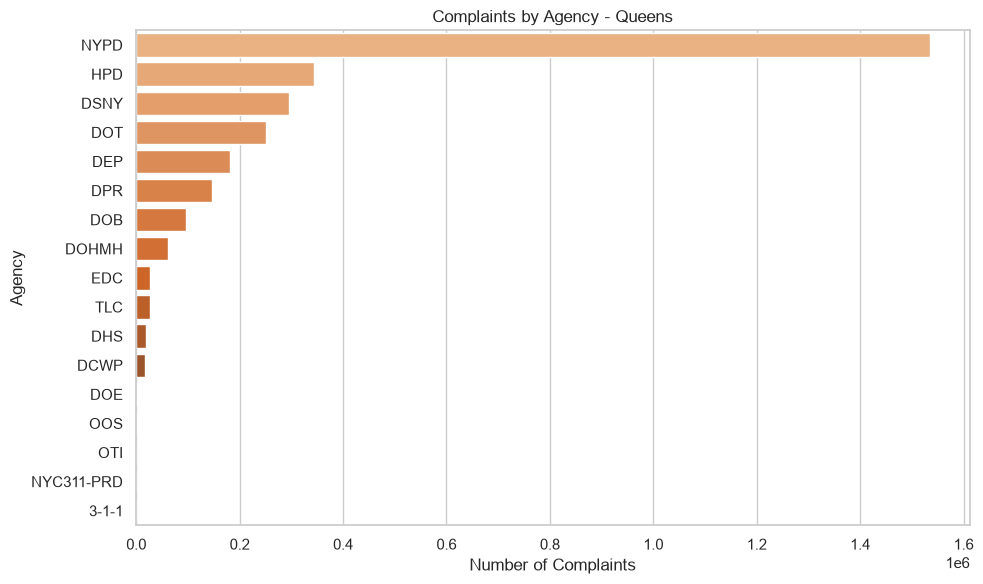

In [74]:
agency_counts = complaints_df['agency'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=agency_counts.values, y=agency_counts.index, palette="Oranges_d")
plt.title('Complaints by Agency - Queens')
plt.xlabel('Number of Complaints')
plt.ylabel('Agency')
plt.tight_layout()
plt.show()

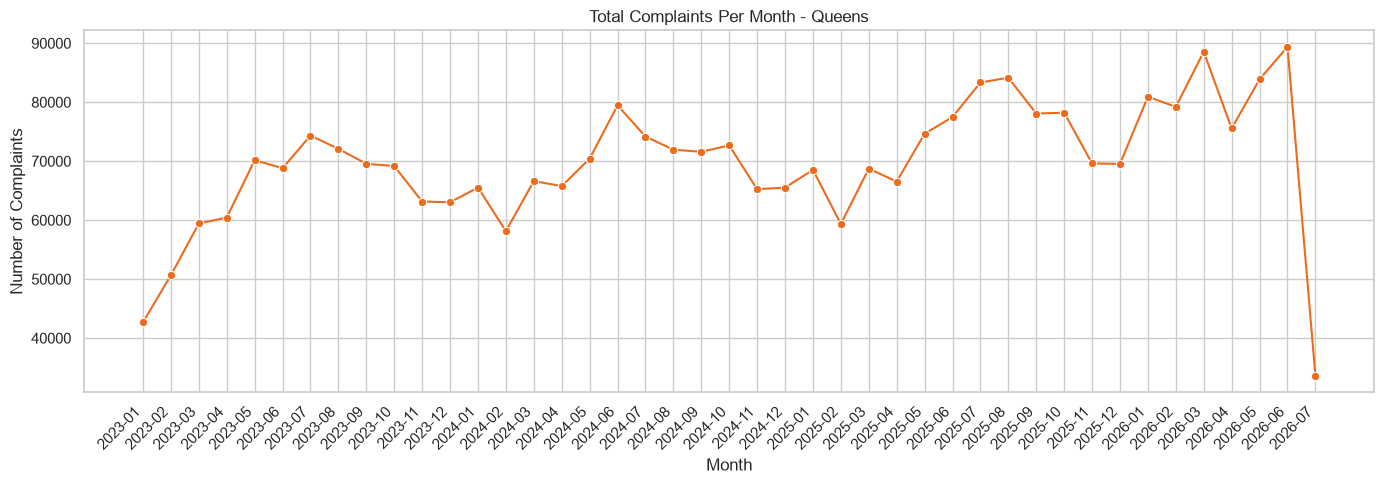

In [75]:
complaints_df['month'] = pd.to_datetime(complaints_df['created_date']).dt.to_period('M')
monthly_complaints = complaints_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=monthly_complaints.index.astype(str), y=monthly_complaints.values, marker='o', color=complaints_colors[2])
plt.title('Total Complaints Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

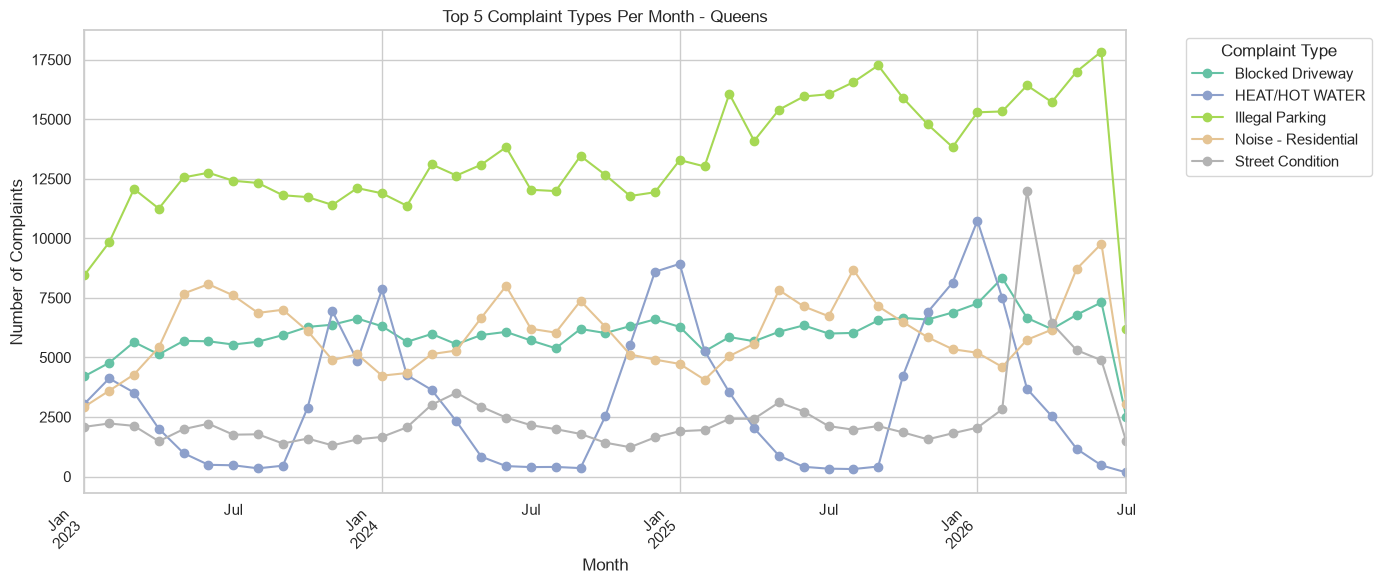

In [78]:
top5 = complaints_df['complaint_type'].value_counts().head(5).index

top5_monthly = (
    complaints_df[complaints_df['complaint_type'].isin(top5)]
    .groupby(['month', 'complaint_type'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 6))
top5_monthly.plot(kind='line', marker='o', colormap='Set2', ax=plt.gca())
plt.title('Top 5 Complaint Types Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Complaint Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()